In [ ]:
import time,json
from collections import OrderedDict, defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.func import functional_call
import matplotlib.pyplot as plt


In [ ]:
torch.manual_seed(0)
DEV = "cpu"

BYTES_PARAM = 2
BYTES_GRAD = 2
BYTES_OPT = 12
BYTES_ACT = 2

In [ ]:
CFG = dict(
    world_size=32, global_batch=256, in_dim=64, d_model=256,
    hidden=1024, depth=6, n_classes=10, steps=30, lr=1e-3,dataset_size=8192,
)

STAGES = ["baseline","zero1","zero2","zero3"]

In [ ]:
## virtual GPU fabric

# =====================================================================
class MemoryTracker:
    """Per-virtual-GPU memory ledger: live bytes per bucket, plus peak."""
    def __init__(self, rank):
        self.rank = rank
        self.buckets = defaultdict(int)
        self.peak = 0
        self.peak_breakdown = {}

    def alloc(self, name, nbytes):
        self.buckets[name] += nbytes
        cur = self.live()
        if cur > self.peak:
            self.peak = cur
            self.peak_breakdown = dict(self.buckets)

    def free(self, name, nbytes=None):
        if nbytes is None:
            self.buckets[name] = 0
        else:
            self.buckets[name] = max(0, self.buckets[name] - nbytes)

    def live(self):
        return sum(self.buckets.values())

    def category_breakdown(self):
        out = defaultdict(int)
        for k, v in self.peak_breakdown.items():
            out[k.split(":")[0]] += v
        return dict(out)


class CommLog:
    """Counts bytes moved, reported per-GPU."""
    def __init__(self):
        self.per_gpu_bytes = 0
        self.ops = defaultdict(int)

    def record(self, op, nbytes):
        self.per_gpu_bytes += nbytes
        self.ops[op] += nbytes

    def reset(self):
        self.per_gpu_bytes = 0
        self.ops.clear()


In [ ]:
class VirtualCluster:
    """N virtual GPUs with explicitly metered ring collectives."""
    def __init__(self, world_size):
        self.N = world_size
        self.mem = [MemoryTracker(r) for r in range(world_size)]
        self.comm = CommLog()

    def all_reduce_mean(self, tensors, elem_bytes=BYTES_GRAD):
        N = self.N
        avg = torch.stack(tensors, 0).mean(0)
        size = tensors[0].numel() * elem_bytes
        self.comm.record("all_reduce", 2.0 * (N - 1) / N * size)
        return avg

    def reduce_scatter_mean(self, tensors, slices, elem_bytes=BYTES_GRAD):
        N = self.N
        full = torch.stack(tensors, 0).mean(0)
        size = tensors[0].numel() * elem_bytes
        self.comm.record("reduce_scatter", (N - 1) / N * size)
        return [full[slices[r][0]:slices[r][1]].clone() for r in range(N)]

    def all_gather(self, shards, elem_bytes=BYTES_PARAM):
        N = self.N
        full = torch.cat(shards, 0)
        self.comm.record("all_gather", (N - 1) / N * full.numel() * elem_bytes)
        return full

    def all_gather_layer(self, lo, hi, elem_bytes=BYTES_PARAM):
        """ZeRO-3: gather a single layer slice. Accounting only."""
        N = self.N
        self.comm.record("all_gather_layer", (N - 1) / N * (hi - lo) * elem_bytes)

    def reset(self):
        for m in self.mem:
            m.buckets.clear(); m.peak = 0; m.peak_breakdown = {}
        self.comm.reset()


def even_slices(numel, N):
    """Contiguous, nearly-equal shards of the flat parameter vector."""
    base, rem = divmod(numel, N)
    out, off = [], 0
    for r in range(N):
        n = base + (1 if r < rem else 0)
        out.append((off, off + n)); off += n
    return out

In [ ]:
# =====================================================================
# 2. Demo model with a flat parameter vector
# =====================================================================
class Block(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.ln, self.fc1, self.fc2 = nn.LayerNorm(d), nn.Linear(d, h), nn.Linear(h, d)

    def forward(self, x):
        return x + self.fc2(F.gelu(self.fc1(self.ln(x))))


class DemoNet(nn.Module):
    def __init__(self, in_dim, d, h, depth, n_classes):
        super().__init__()
        self.inp = nn.Linear(in_dim, d)
        self.blocks = nn.ModuleList([Block(d, h) for _ in range(depth)])
        self.head = nn.Linear(d, n_classes)

    def forward(self, x):
        x = self.inp(x)
        for b in self.blocks:
            x = b(x)
        return self.head(x)


class FlatModel:
    """All parameters in ONE flat vector, so sharding is a contiguous slice."""
    def __init__(self, cfg):
        torch.manual_seed(1234)                 # identical init every stage
        self.net = DemoNet(cfg["in_dim"], cfg["d_model"], cfg["hidden"],
                           cfg["depth"], cfg["n_classes"]).to(DEV)
        self.meta, chunks, off = [], [], 0
        for name, p in self.net.named_parameters():
            n = p.numel()
            self.meta.append((name, tuple(p.shape), off, n))
            chunks.append(p.detach().reshape(-1)); off += n
        self.numel = off
        self.init_flat = torch.cat(chunks).clone()
        for p in self.net.parameters():
            p.requires_grad_(False)
        self.layer_ranges = self._layer_ranges()

    def _layer_ranges(self):
        g = OrderedDict()
        for name, _, off, n in self.meta:
            parts = name.split(".")
            key = f"{parts[0]}.{parts[1]}" if parts[0] == "blocks" else parts[0]
            lo, hi = g.get(key, (off, off))
            g[key] = (min(lo, off), max(hi, off + n))
        return list(g.items())

    def unflatten(self, flat):
        return {name: flat[off:off + n].view(shape)
                for (name, shape, off, n) in self.meta}

    def grad(self, flat, x, y):
        f = flat.detach().clone().requires_grad_(True)
        out = functional_call(self.net, self.unflatten(f), (x,))
        l = F.cross_entropy(out, y)
        (g,) = torch.autograd.grad(l, f)
        return l.detach(), g


def activation_bytes(cfg, micro_bs):
    d, h, L = cfg["d_model"], cfg["hidden"], cfg["depth"]
    total = micro_bs * (3 * d + 2 * h) * L + micro_bs * (cfg["in_dim"] + d)
    return int(total * BYTES_ACT)


# =====================================================================
# 3. Dataset
# =====================================================================
def make_dataset(cfg, seed=7):
    g = torch.Generator().manual_seed(seed)
    n, k = cfg["dataset_size"], cfg["n_classes"]
    centers = torch.randn(k, cfg["in_dim"], generator=g) * 2.0
    y = torch.randint(0, k, (n,), generator=g)
    x = centers[y] + torch.randn(n, cfg["in_dim"], generator=g) * 1.5
    return x.to(DEV), y.to(DEV)


X, Y = make_dataset(CFG)


def get_batch(step, cfg):
    B, n = cfg["global_batch"], X.shape[0]
    idx = torch.arange(step * B, step * B + B) % n
    return X[idx], Y[idx]


In [ ]:
# =====================================================================
# 4. Sharded Adam
# =====================================================================
class ShardedAdam:
    """Adam over a contiguous slice [lo, hi) of the flat vector."""
    def __init__(self, lo, hi, lr, b1=0.9, b2=0.999, eps=1e-8):
        self.lo, self.hi, self.lr = lo, hi, lr
        self.b1, self.b2, self.eps = b1, b2, eps
        n = hi - lo
        self.m = torch.zeros(n, device=DEV)
        self.v = torch.zeros(n, device=DEV)
        self.t = 0

    def step(self, p, g):
        self.t += 1
        self.m.mul_(self.b1).add_(g, alpha=1 - self.b1)
        self.v.mul_(self.b2).addcmul_(g, g, value=1 - self.b2)
        mhat = self.m / (1 - self.b1 ** self.t)
        vhat = self.v / (1 - self.b2 ** self.t)
        return p - self.lr * mhat / (vhat.sqrt() + self.eps)

    def state_bytes(self):
        return (self.hi - self.lo) * BYTES_OPT

In [ ]:
# =====================================================================
# 5. Trainer: baseline + ZeRO-1/2/3
# =====================================================================
def run(stage, cfg, steps=None, verbose=False, trace=False, trace_steps=(0,)):
    assert stage in STAGES
    N = cfg["world_size"]
    steps = steps or cfg["steps"]
    cl = VirtualCluster(N)
    model = FlatModel(cfg)
    psi = model.numel
    slices = even_slices(psi, N)
    flat = model.init_flat.clone()

    shard_opt   = stage in ("zero1", "zero2", "zero3")
    shard_grad  = stage in ("zero2", "zero3")
    shard_param = stage == "zero3"

    if stage == "baseline":
        opt, opts = ShardedAdam(0, psi, cfg["lr"]), None
    else:
        opt = None
        opts = [ShardedAdam(*slices[r], cfg["lr"]) for r in range(N)]

    micro   = cfg["global_batch"] // N
    act_b   = activation_bytes(cfg, micro)
    biggest = max(hi - lo for _, (lo, hi) in model.layer_ranges)
    losses, step_times = [], []
    timeline = []

    def snap(step, phase):
        """Record rank-0 memory + cumulative comm at a phase boundary."""
        if not trace or step not in trace_steps:
            return
        timeline.append(dict(
            step=step, phase=phase,
            live_mb=cl.mem[0].live() / 1e6,
            comm_mb=cl.comm.per_gpu_bytes / 1e6,
            buckets={k: round(v / 1e6, 3)
                     for k, v in cl.mem[0].buckets.items() if v > 0},
        ))

    for step in range(steps):
        t0 = time.time()
        for m in cl.mem:
            m.buckets.clear()

        # --- 1. resident parameters ---
        for r in range(N):
            nb = ((slices[r][1] - slices[r][0]) if shard_param else psi) * BYTES_PARAM
            cl.mem[r].alloc("param", nb)
        snap(step, "1_params_resident")

        # --- 2. resident optimizer state ---
        for r in range(N):
            nb = opts[r].state_bytes() if shard_opt else psi * BYTES_OPT
            cl.mem[r].alloc("optimizer", nb)
        snap(step, "2_optimizer_resident")

        # --- 3. forward + backward per virtual GPU ---
        xb, yb = get_batch(step, cfg)
        grads, ls = [], []
        for r in range(N):
            mb_x = xb[r * micro:(r + 1) * micro]
            mb_y = yb[r * micro:(r + 1) * micro]
            l, g = model.grad(flat, mb_x, mb_y)
            ls.append(l); grads.append(g)

            cl.mem[r].alloc("activations", act_b)

            if shard_param:
                # gather one layer, use it, free it -> peak is the largest layer
                cl.mem[r].alloc("param_gather_transient", biggest * BYTES_PARAM)
                for _, (lo, hi) in model.layer_ranges:
                    cl.all_gather_layer(lo, hi)    # forward gather
                    cl.all_gather_layer(lo, hi)    # backward re-gather
                cl.mem[r].free("param_gather_transient")

            cl.mem[r].alloc("grad", psi * BYTES_GRAD)

        losses.append(float(torch.stack(ls).mean()))
        snap(step, "3_after_fwd_bwd")

          # --- 4/5. reduce, update, restore ---
        if stage == "baseline":
            flat = opt.step(flat, cl.all_reduce_mean(grads))
            snap(step, "4_after_all_reduce")
        else:
            shard_grads = cl.reduce_scatter_mean(grads, slices)
            if shard_grad:
                for r in range(N):
                    cl.mem[r].free("grad")
                    cl.mem[r].alloc("grad",
                                    (slices[r][1] - slices[r][0]) * BYTES_GRAD)
            snap(step, "4_after_reduce_scatter")
            new_shards = [opts[r].step(flat[slices[r][0]:slices[r][1]],
                                       shard_grads[r]) for r in range(N)]

            flat = cl.all_gather(new_shards)
        snap(step, "5_after_update")

        step_times.append(time.time() - t0)
        if verbose and step % 10 == 0:
            print(f"  step {step:3d}  loss {losses[-1]:.4f}")

    peaks = [m.peak for m in cl.mem]
    return dict(
        stage=stage, world_size=N, psi=psi, losses=losses,
        peak_bytes=max(peaks),
        peak_min=min(peaks),
        peak_spread=(max(peaks) - min(peaks)) / max(peaks),
        breakdown=cl.mem[0].category_breakdown(),
        comm_per_gpu=cl.comm.per_gpu_bytes / steps,
        comm_ops={k: v / steps for k, v in cl.comm.ops.items()},
        step_time=sum(step_times) / len(step_times),
        timeline=timeline,
    )

A. COMM COST MODEL CHECK
  all_reduce            = 3875.0 bytes/GPU
  reduce_scatter+gather = 3875.0 bytes/GPU
  equal? True <-- why ZeRO-1/2 cost no extra comm

  parameters Psi = 3,175,690
  layer groups    = 8
  micro-batch     = 8 per GPU x 32 GPUs
  DDP weight state/GPU = 16*Psi = 50.81 MB

B. TRAINING RUNS (N=32, 30 steps)
  baseline  | peak/GPU    51.09 MB | comm/GPU/step   12.31 MB | final loss 0.00001 | 96.4s
  zero1     | peak/GPU    14.17 MB | comm/GPU/step   12.31 MB | final loss 0.00001 | 97.9s
  zero2     | peak/GPU    14.17 MB | comm/GPU/step   12.31 MB | final loss 0.00001 | 102.4s
  zero3     | peak/GPU     8.02 MB | comm/GPU/step  406.09 MB | final loss 0.00001 | 100.5s

C. CORRECTNESS: ZeRO must not change the math
  zero1    max|d_loss| = 0.000e+00  PASS
  zero2    max|d_loss| = 0.000e+00  PASS
  zero3    max|d_loss| = 0.000e+00  PASS
  All ZeRO stages are mathematically equivalent to data parallel.

D. INTRA-STEP MEMORY TIMELINE (rank 0, step 0)

 --- baseline ---


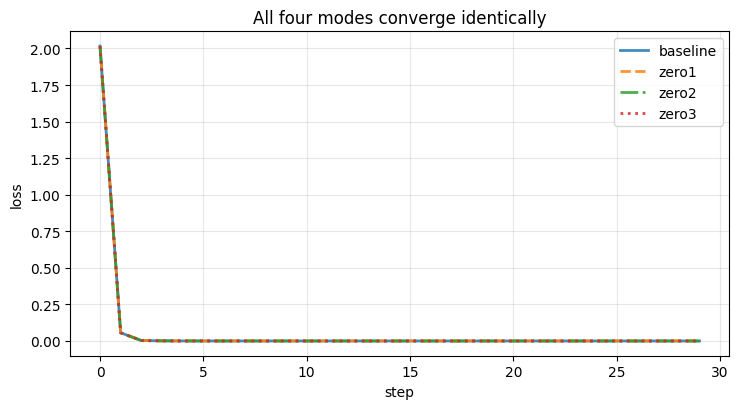

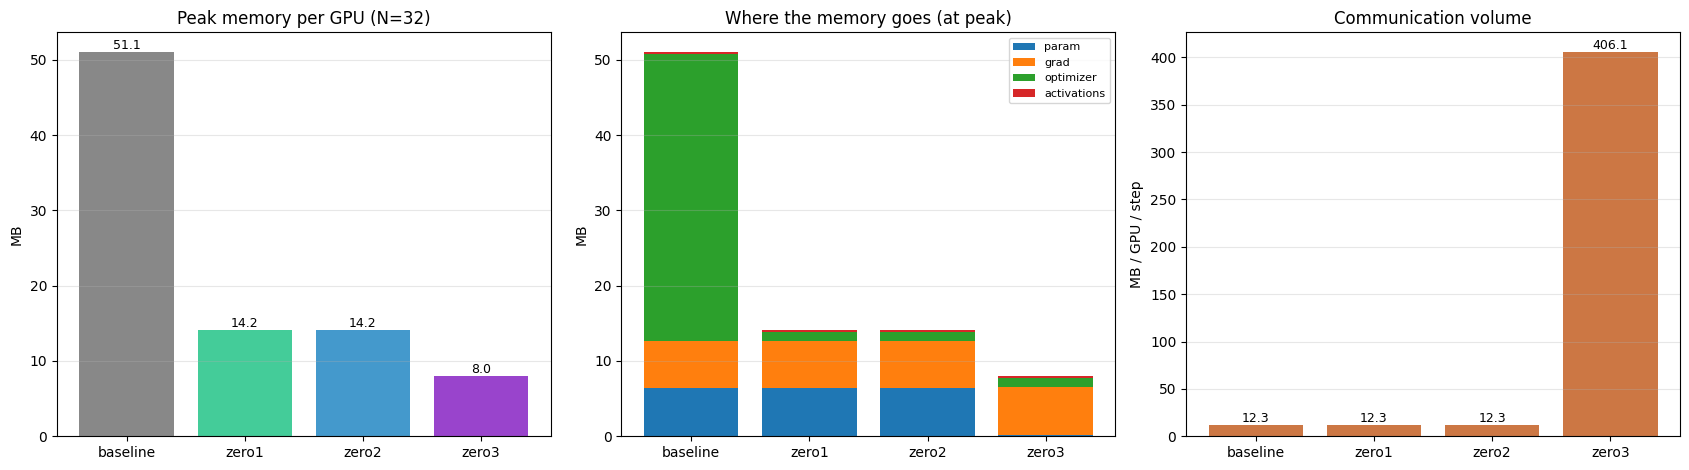

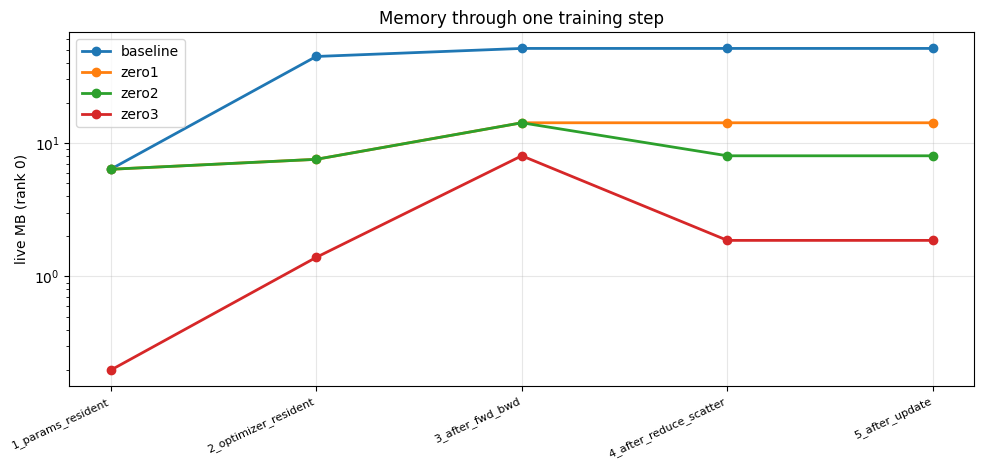


H. SCALING SWEEP
  N= 1 baseline=59.6 zero1=59.6 zero2=59.6 zero3=59.6
  N= 2 baseline=55.2 zero1=36.2 zero2=36.2 zero3=33.0
  N= 4 baseline=53.0 zero1=24.4 zero2=24.4 zero3=19.7
  N= 8 baseline=51.9 zero1=18.6 zero2=18.6 zero3=13.0
  N=16 baseline=51.4 zero1=15.6 zero2=15.6 zero3=9.7
  N=32 baseline=51.1 zero1=14.2 zero2=14.2 zero3=8.0


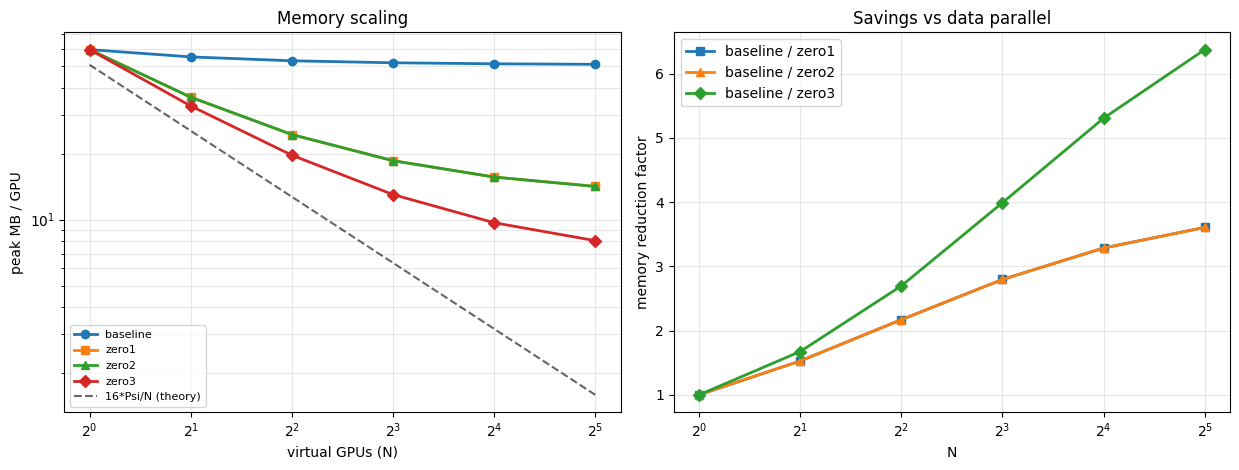


I. SUMMARY VS THEORY

I. SUMMARY vs THEORY
  stage       measured MB   theory MB   comm MB   vs DDP   s/step
  ---------------------------------------------------------------
  baseline          51.09       50.81     12.31    1.00x    3.212
  zero1             14.17       13.89     12.31    3.61x    3.262
  zero2             14.17        7.74     12.31    3.61x    3.412
  zero3              8.02        1.59    406.09    6.37x    3.347

  Comm op breakdown (MB/GPU/step):
  baseline   {'all_reduce': 12.31}
  zero1      {'reduce_scatter': 6.15, 'all_gather': 6.15}
  zero2      {'reduce_scatter': 6.15, 'all_gather': 6.15}
  zero3      {'all_gather_layer': 393.79, 'reduce_scatter': 6.15, 'all_gather': 6.15}

  Activation memory (same in every stage): 0.275 MB
  That is the gap between measured and theory -- ZeRO does not
  shard activations. That is what activation checkpointing is for.

  Saved -> zero_results.json


In [ ]:
# =====================================================================
# 6. Main
# =====================================================================
def main():
    # ---------- A. comm cost-model sanity check ----------
    print("=" * 78)
    print("A. COMM COST MODEL CHECK")
    print("=" * 78)
    cl = VirtualCluster(32)
    t = [torch.zeros(1000) for _ in range(32)]
    cl.all_reduce_mean(t); ar = cl.comm.per_gpu_bytes
    cl.reset()
    sl = even_slices(1000, 32)
    cl.reduce_scatter_mean(t, sl)
    cl.all_gather([torch.zeros(b - a) for a, b in sl])
    rsag = cl.comm.per_gpu_bytes
    print(f"  all_reduce            = {ar:.1f} bytes/GPU")
    print(f"  reduce_scatter+gather = {rsag:.1f} bytes/GPU")
    print(f"  equal? {abs(ar - rsag) < 1e-6} <-- why ZeRO-1/2 cost no extra comm")

    fm = FlatModel(CFG)
    PSI = fm.numel
    micro = CFG["global_batch"] // CFG["world_size"]
    print(f"\n  parameters Psi = {PSI:,}")
    print(f"  layer groups    = {len(fm.layer_ranges)}")
    print(f"  micro-batch     = {micro} per GPU x {CFG['world_size']} GPUs")
    print(f"  DDP weight state/GPU = 16*Psi = {PSI * 16 / 1e6:.2f} MB")

    # ---------- B. run all four modes ----------
    print("\n" + "=" * 78)
    print(f"B. TRAINING RUNS (N={CFG['world_size']}, {CFG['steps']} steps)")
    print("=" * 78)
    results = {}
    for s in STAGES:
        t0 = time.time()
        r = results[s] = run(s, CFG)
        print(f"  {s:9s} | peak/GPU {r['peak_bytes']/1e6:8.2f} MB "
              f"| comm/GPU/step {r['comm_per_gpu']/1e6:7.2f} MB "
              f"| final loss {r['losses'][-1]:.5f} "
              f"| {time.time()-t0:.1f}s")

    # ---------- C. correctness ----------
    print("\n" + "=" * 78)
    print("C. CORRECTNESS: ZeRO must not change the math")
    print("=" * 78)
    base = torch.tensor(results["baseline"]["losses"])
    for s in STAGES[1:]:
        d = (torch.tensor(results[s]["losses"]) - base).abs().max().item()
        assert d < 1e-4, f"{s} diverged from baseline"
        print(f"  {s:8s} max|d_loss| = {d:.3e}  PASS")
    print("  All ZeRO stages are mathematically equivalent to data parallel.")

    # ---------- D. intra-step memory timeline ----------
    print("\n" + "=" * 78)
    print("D. INTRA-STEP MEMORY TIMELINE (rank 0, step 0)")
    print("=" * 78)
    for s in STAGES:
        tr = run(s, CFG, steps=1, trace=True)
        print(f"\n --- {s} ---")
        for e in tr["timeline"]:
            print(f"    {e['phase']:24s} live={e['live_mb']:8.2f} MB  "
                  f"f'comm={e['comm_mb']:7.2f} MB')")
            print(f"    {'':24s} {e['buckets']}")
    print("\n  Watch live_mb between phase 3 and 4: it DROPS for zero2/zero3")
    print("  (full grad buffer -> 1/N shard) and stays FLAT for baseline/zero1.")
    print("  Watch comm_mb at phase 3: only zero3 climbs (parameter gathers).")

    # ---------- E. per-rank balance ----------
    print("\n" + "=" * 78)
    print("E. PER-RANK BALANCE")
    print("=" * 78)
    for s in STAGES:
        r = results[s]
        print(f"  {s:10s} max={r['peak_bytes']/1e6:8.2f} MB  "
              f"f'min={r['peak_min']/1e6:8.2f} MB  "
              f"f'spread={r['peak_spread']*100:.2f}%')")

    # ---------- F. plots ----------
    plt.figure(figsize=(7.5, 4.2))
    for st, s in zip(["-", "--", "-.", ":"], STAGES):
        plt.plot(results[s]["losses"], st, label=s, linewidth=2, alpha=.85)
    plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=.3)
    plt.title("All four modes converge identically"); plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    ax = axes[0]
    vals = [results[s]["peak_bytes"] / 1e6 for s in STAGES]
    ax.bar(STAGES, vals, color=["#888", "#4c9", "#49c", "#94c"])
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("MB"); ax.grid(axis="y", alpha=.3)
    ax.set_title(f"Peak memory per GPU (N={CFG['world_size']})")

    ax = axes[1]
    bottom = [0.0] * len(STAGES)
    for c in ["param", "grad", "optimizer", "activations",
              "param_gather_transient"]:
        h = [results[s]["breakdown"].get(c, 0) / 1e6 for s in STAGES]
        if sum(h) == 0:
            continue
        ax.bar(STAGES, h, bottom=bottom, label=c)
        bottom = [b + x for b, x in zip(bottom, h)]
    ax.set_ylabel("MB"); ax.set_title("Where the memory goes (at peak)")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=.3)

    ax = axes[2]
    cv = [results[s]["comm_per_gpu"] / 1e6 for s in STAGES]
    ax.bar(STAGES, cv, color="#c74")
    for i, v in enumerate(cv):
        ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("MB / GPU / step"); ax.set_title("Communication volume")
    ax.grid(axis="y", alpha=.3)
    plt.tight_layout(); plt.show()

    # ---------- G. timeline plot ----------
    fig, ax = plt.subplots(figsize=(10, 4.8))
    for s in STAGES:
        tr = run(s, CFG, steps=1, trace=True)
        ys = [e["live_mb"] for e in tr["timeline"]]
        xs = list(range(len(ys)))
        ax.plot(xs, ys, marker="o", label=s, linewidth=2)
        labels = [e["phase"] for e in tr["timeline"]]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("live MB (rank 0)"); ax.set_yscale("log")
    ax.set_title("Memory through one training step")
    ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

    # ---------- H. scaling sweep ----------
    NS = [1, 2, 4, 8, 16, 32]
    sweep = {s: [] for s in STAGES}
    print("\n" + "=" * 78)
    print("H. SCALING SWEEP")
    print("=" * 78)
    for n in NS:
        cfg = dict(CFG); cfg["world_size"] = n
        for s in STAGES:
            sweep[s].append(run(s, cfg, steps=3)["peak_bytes"] / 1e6)
        print(f"  N={n:2d} " +
              " ".join(f"{s}={sweep[s][-1]:.1f}" for s in STAGES))

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
    ax = axes[0]
    for mk, s in zip(["o", "s", "^", "D"], STAGES):
        ax.plot(NS, sweep[s], marker=mk, label=s, linewidth=2)
    ax.plot(NS, [PSI * 16 / n / 1e6 for n in NS], "--k", alpha=.6,
            label="16*Psi/N (theory)")
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_xlabel("virtual GPUs (N)"); ax.set_ylabel("peak MB / GPU")
    ax.set_title("Memory scaling"); ax.legend(fontsize=8)
    ax.grid(alpha=.3, which="both")

    ax = axes[1]
    for mk, s in zip(["s", "^", "D"], STAGES[1:]):
        ax.plot(NS, [sweep["baseline"][i] / sweep[s][i] for i in range(len(NS))],
                marker=mk, label=f"baseline / {s}", linewidth=2)
    ax.set_xscale("log", base=2); ax.set_xlabel("N")
    ax.set_ylabel("memory reduction factor")
    ax.set_title("Savings vs data parallel"); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

    # ---------- I. summary vs theory ----------
    N = CFG["world_size"]
    theory = {
        "baseline": 16.0 * PSI,
        "zero1":    4.0 * PSI + 12.0 * PSI / N,
        "zero2":    2.0 * PSI + 14.0 * PSI / N,
        "zero3":    16.0 * PSI / N,
    }

    print("\n" + "=" * 78)
    print("I. SUMMARY VS THEORY")
    print("=" * 78)

    # ---------- I. summary vs theory ----------
    N = CFG["world_size"]
    theory = {
        "baseline": 16.0 * PSI,
        "zero1":    4.0 * PSI + 12.0 * PSI / N,
        "zero2":    2.0 * PSI + 14.0 * PSI / N,
        "zero3":    16.0 * PSI / N,
    }

    print("\n" + "=" * 78)
    print("I. SUMMARY vs THEORY")
    print("=" * 78)
    print(f"  {'stage':10s}{'measured MB':>13s}{'theory MB':>12s}"
          f"{'comm MB':>10s}{'vs DDP':>9s}{'s/step':>9s}")
    print("  " + "-" * 63)
    b = results["baseline"]["peak_bytes"]
    for s in STAGES:
        r = results[s]
        print(f"  {s:10s}{r['peak_bytes']/1e6:13.2f}{theory[s]/1e6:12.2f}"
              f"{r['comm_per_gpu']/1e6:10.2f}"
              f"{b/r['peak_bytes']:8.2f}x{r['step_time']:9.3f}")

    print("\n  Comm op breakdown (MB/GPU/step):")
    for s in STAGES:
        print(f"  {s:10s}",
              {k: round(v / 1e6, 2) for k, v in results[s]["comm_ops"].items()})

    act = results["baseline"]["breakdown"].get("activations", 0) / 1e6
    print(f"\n  Activation memory (same in every stage): {act:.3f} MB")
    print("  That is the gap between measured and theory -- ZeRO does not")
    print("  shard activations. That is what activation checkpointing is for.")

    with open("zero_results.json", "w") as f:
        json.dump({s: {k: v for k, v in results[s].items()
                       if k not in ("losses", "timeline")}
                   for s in STAGES}, f, indent=2)
    print("\n  Saved -> zero_results.json")


if __name__ == "__main__":
    main()